# Análise Inicial de Dados - Tênis de Corrida RunRepeat

## 3. Visualização de Dados Univariada (1D)

**Dataset:** 530 tênis de corrida extraídos do site RunRepeat

Nesta análise, aplicaremos visualizações univariadas para entender a distribuição de atributos individuais:
1. **Gráfico de barras** - Para atributos categóricos
2. **Histograma** - Para atributos numéricos contínuos
3. **Boxplot** - Para detectar outliers e analisar distribuição

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configurações
sns.set_style('whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)

# Carregar dados
df = pd.read_csv('tenis_scraper_runrepeat/dados_finais/runrepeat_shoes_complete.csv')
print(f"Dataset carregado: {df.shape[0]} linhas x {df.shape[1]} colunas")

Dataset carregado: 530 linhas x 46 colunas


## 3.1 Gráficos de Barras - Atributos Categóricos

### Justificativa:
Gráficos de barras são ideais para visualizar a **frequência** de categorias em atributos nominais e ordinais. Permitem identificar:
- Categorias mais e menos frequentes
- Desbalanceamento entre categorias
- Distribuição geral dos dados categóricos

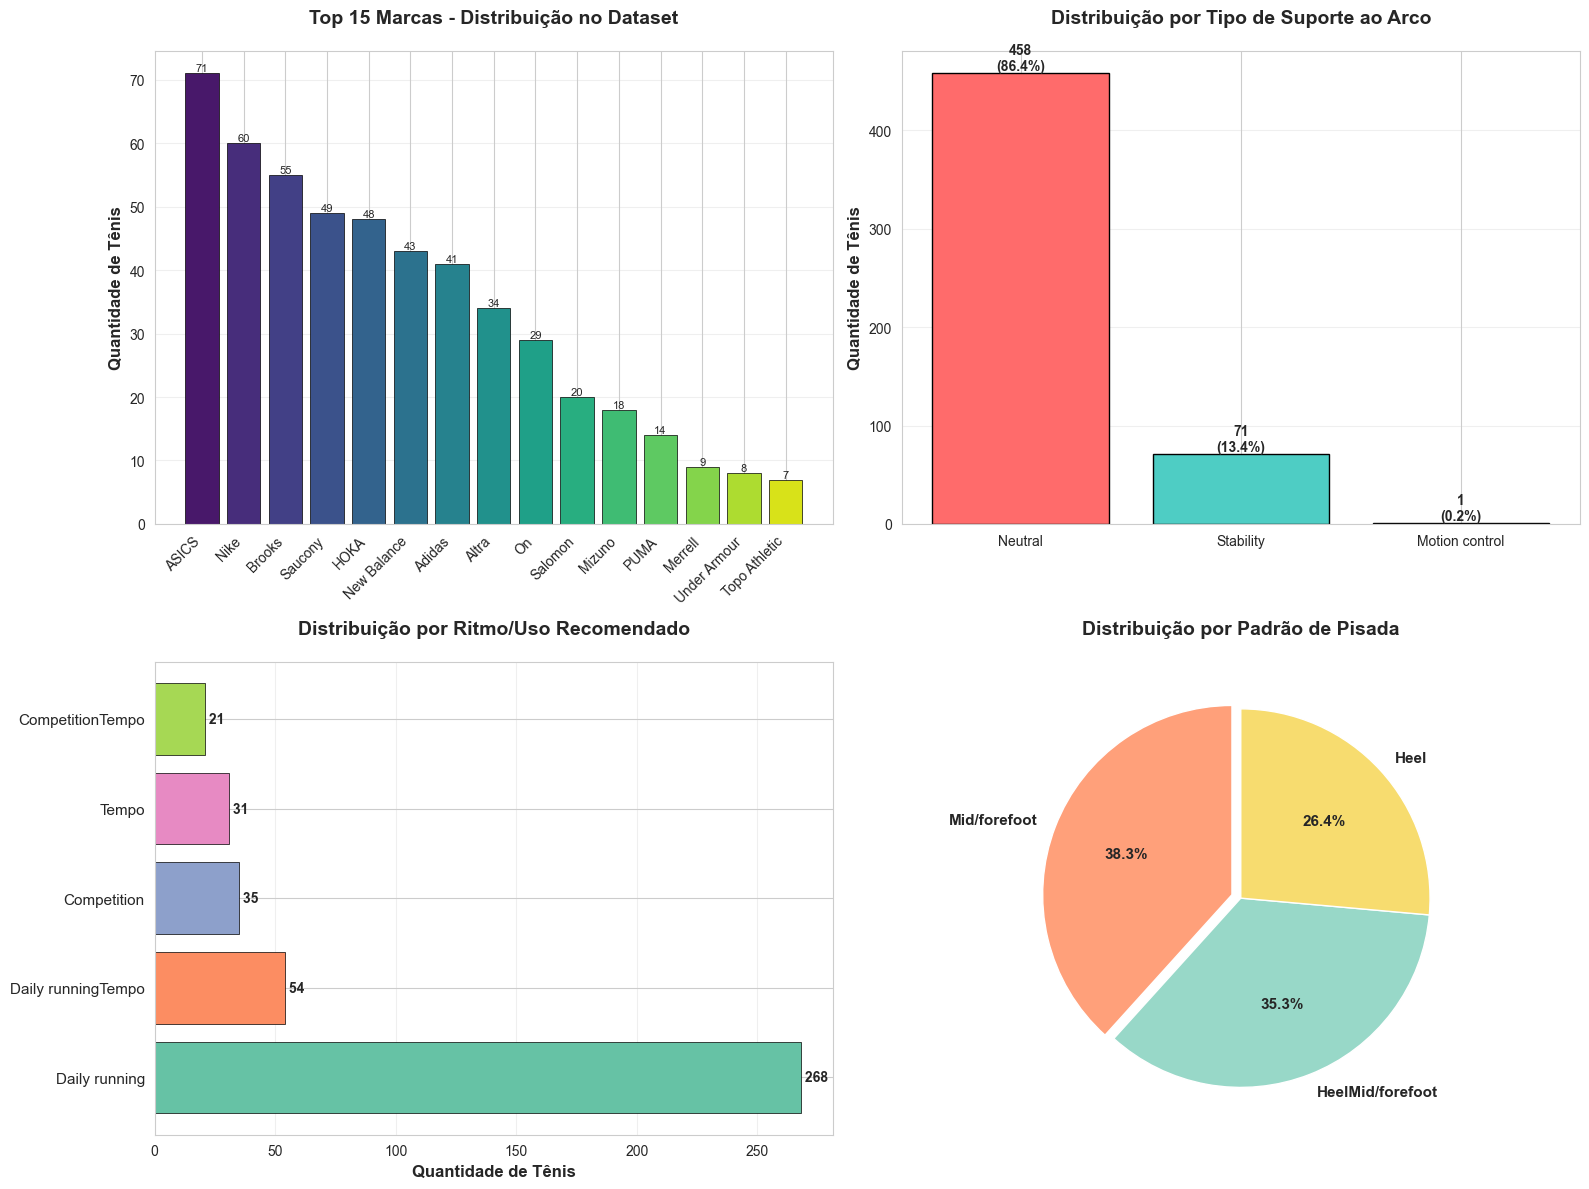


 INTERPRETAÇÃO - Gráficos de Barras:
• As 3 marcas mais frequentes representam 35.1% do dataset
• Neutral é o tipo de suporte mais comum (86.4%)
• A maioria dos tênis é recomendada para: Daily running
• Padrão de pisada dominante: Mid/forefoot


In [2]:
# Análise 1: Distribuição por Marca
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Gráfico 1: Top 15 Marcas
ax1 = axes[0, 0]
brand_counts = df['brand'].value_counts().head(15)
colors1 = sns.color_palette('viridis', len(brand_counts))
bars1 = ax1.bar(range(len(brand_counts)), brand_counts.values, color=colors1, edgecolor='black', linewidth=0.5)
ax1.set_xticks(range(len(brand_counts)))
ax1.set_xticklabels(brand_counts.index, rotation=45, ha='right', fontsize=10)
ax1.set_ylabel('Quantidade de Tênis', fontsize=12, fontweight='bold')
ax1.set_title('Top 15 Marcas - Distribuição no Dataset', fontsize=14, fontweight='bold', pad=20)
ax1.grid(axis='y', alpha=0.3)

# Adicionar valores nas barras
for i, bar in enumerate(bars1):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=8)

# Gráfico 2: Tipo de Suporte ao Arco
ax2 = axes[0, 1]
support_counts = df['arch support'].value_counts()
colors2 = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars2 = ax2.bar(support_counts.index, support_counts.values, color=colors2, edgecolor='black', linewidth=1)
ax2.set_ylabel('Quantidade de Tênis', fontsize=12, fontweight='bold')
ax2.set_title('Distribuição por Tipo de Suporte ao Arco', fontsize=14, fontweight='bold', pad=20)
ax2.grid(axis='y', alpha=0.3)

# Adicionar valores e percentuais
for i, bar in enumerate(bars2):
    height = bar.get_height()
    pct = (height / len(df)) * 100
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Gráfico 3: Ritmo/Uso Recomendado
ax3 = axes[1, 0]
pace_counts = df['pace'].value_counts()
colors3 = sns.color_palette('Set2', len(pace_counts))
bars3 = ax3.barh(range(len(pace_counts)), pace_counts.values, color=colors3, edgecolor='black', linewidth=0.5)
ax3.set_yticks(range(len(pace_counts)))
ax3.set_yticklabels(pace_counts.index, fontsize=11)
ax3.set_xlabel('Quantidade de Tênis', fontsize=12, fontweight='bold')
ax3.set_title('Distribuição por Ritmo/Uso Recomendado', fontsize=14, fontweight='bold', pad=20)
ax3.grid(axis='x', alpha=0.3)

# Adicionar valores
for i, bar in enumerate(bars3):
    width = bar.get_width()
    ax3.text(width, bar.get_y() + bar.get_height()/2.,
            f' {int(width)}',
            ha='left', va='center', fontsize=10, fontweight='bold')

# Gráfico 4: Padrão de Pisada
ax4 = axes[1, 1]
strike_counts = df['strike pattern'].value_counts()
colors4 = ['#FFA07A', '#98D8C8', '#F7DC6F']
explode = [0.05 if i == 0 else 0 for i in range(len(strike_counts))]
wedges, texts, autotexts = ax4.pie(strike_counts.values, labels=strike_counts.index,
                                     autopct='%1.1f%%', colors=colors4, explode=explode,
                                     startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
ax4.set_title('Distribuição por Padrão de Pisada', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print("\n INTERPRETAÇÃO - Gráficos de Barras:")
print("="*80)
print(f"• As 3 marcas mais frequentes representam {(brand_counts.head(3).sum()/len(df)*100):.1f}% do dataset")
print(f"• {support_counts.index[0]} é o tipo de suporte mais comum ({support_counts.iloc[0]/len(df)*100:.1f}%)")
print(f"• A maioria dos tênis é recomendada para: {pace_counts.index[0]}")
print(f"• Padrão de pisada dominante: {strike_counts.index[0]}")

## 3.2 Histogramas - Atributos Numéricos

### Justificativa:
Histogramas são essenciais para visualizar a **distribuição de frequência** de variáveis contínuas. Permitem identificar:
- Forma da distribuição (normal, assimétrica, bimodal)
- Tendência central e dispersão
- Presença de valores extremos
- Padrões e agrupamentos nos dados

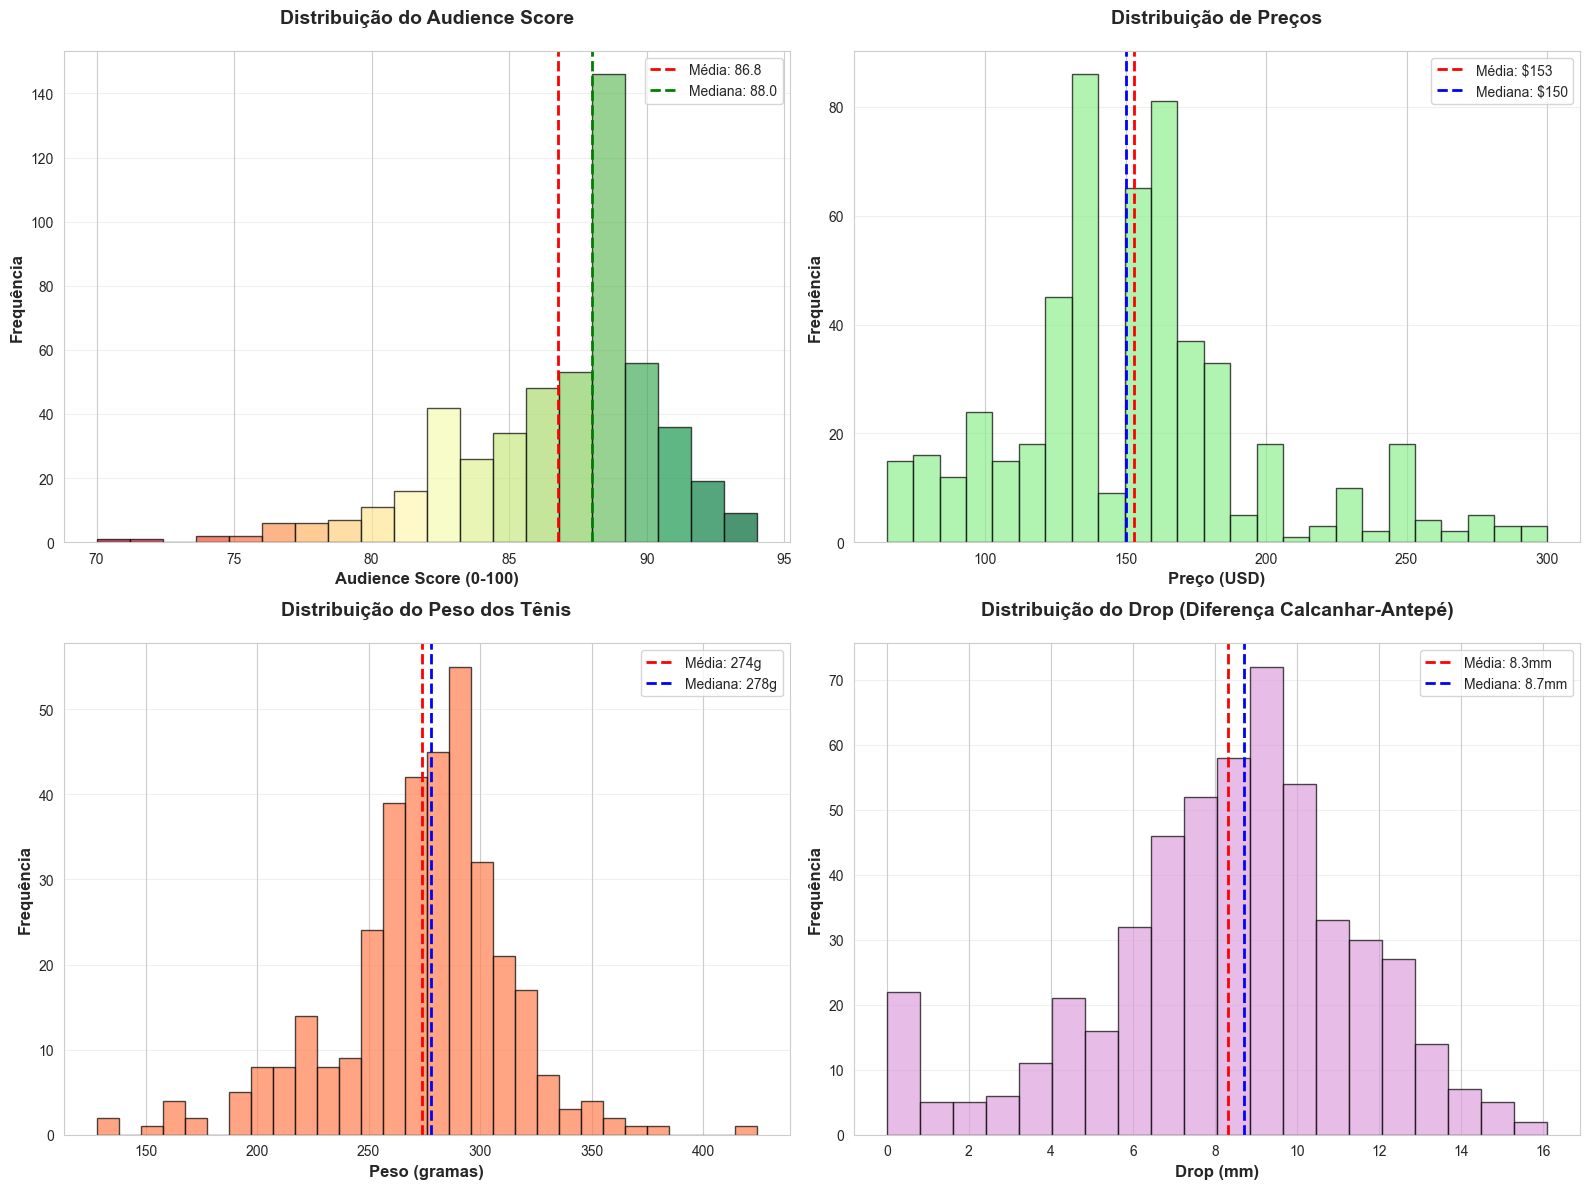


 INTERPRETAÇÃO - Histogramas:

1  AUDIENCE SCORE:
   • Média: 86.8 | Mediana: 88.0
   • Amplitude: [70.0, 94.0]
   • Distribuição: Assimétrica à esquerda

2  PREÇO:
   • Média: $153.09 | Mediana: $150.00
   • Amplitude: [$65, $300]
   • 50% dos tênis custam entre $130 e $170

3  PESO:
   • Média: 273.9g | Mediana: 278.0g
   • Amplitude: [128g, 424g]
   • Categoria típica: Moderado

4  DROP:
   • Média: 8.32mm | Mediana: 8.70mm
   • Amplitude: m, 16mm]
   • Drop mais comum: 9.6mm


In [3]:
# Análise de atributos numéricos principais
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Histograma 1: Audience Score
ax1 = axes[0, 0]
scores = df['audience_score'].dropna()
n1, bins1, patches1 = ax1.hist(scores, bins=20, color='skyblue', edgecolor='black', alpha=0.7)

# Colorir barras por gradiente
cm = plt.cm.get_cmap('RdYlGn')
bin_centers = 0.5 * (bins1[:-1] + bins1[1:])
col = bin_centers - min(bin_centers)
col /= max(col)
for c, p in zip(col, patches1):
    plt.setp(p, 'facecolor', cm(c))

ax1.axvline(scores.mean(), color='red', linestyle='--', linewidth=2, label=f'Média: {scores.mean():.1f}')
ax1.axvline(scores.median(), color='green', linestyle='--', linewidth=2, label=f'Mediana: {scores.median():.1f}')
ax1.set_xlabel('Audience Score (0-100)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Frequência', fontsize=12, fontweight='bold')
ax1.set_title('Distribuição do Audience Score', fontsize=14, fontweight='bold', pad=20)
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)

# Histograma 2: Preço (USD)
ax2 = axes[0, 1]
prices = df['price_usd'].dropna()
ax2.hist(prices, bins=25, color='lightgreen', edgecolor='black', alpha=0.7)
ax2.axvline(prices.mean(), color='red', linestyle='--', linewidth=2, label=f'Média: ${prices.mean():.0f}')
ax2.axvline(prices.median(), color='blue', linestyle='--', linewidth=2, label=f'Mediana: ${prices.median():.0f}')
ax2.set_xlabel('Preço (USD)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Frequência', fontsize=12, fontweight='bold')
ax2.set_title('Distribuição de Preços', fontsize=14, fontweight='bold', pad=20)
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3)

# Histograma 3: Peso (gramas)
ax3 = axes[1, 0]
weights = df['weight_grams'].dropna()
ax3.hist(weights, bins=30, color='coral', edgecolor='black', alpha=0.7)
ax3.axvline(weights.mean(), color='red', linestyle='--', linewidth=2, label=f'Média: {weights.mean():.0f}g')
ax3.axvline(weights.median(), color='blue', linestyle='--', linewidth=2, label=f'Mediana: {weights.median():.0f}g')
ax3.set_xlabel('Peso (gramas)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Frequência', fontsize=12, fontweight='bold')
ax3.set_title('Distribuição do Peso dos Tênis', fontsize=14, fontweight='bold', pad=20)
ax3.legend(fontsize=10)
ax3.grid(axis='y', alpha=0.3)

# Histograma 4: Drop (mm)
ax4 = axes[1, 1]
drops = df['drop_mm'].dropna()
ax4.hist(drops, bins=20, color='plum', edgecolor='black', alpha=0.7)
ax4.axvline(drops.mean(), color='red', linestyle='--', linewidth=2, label=f'Média: {drops.mean():.1f}mm')
ax4.axvline(drops.median(), color='blue', linestyle='--', linewidth=2, label=f'Mediana: {drops.median():.1f}mm')
ax4.set_xlabel('Drop (mm)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Frequência', fontsize=12, fontweight='bold')
ax4.set_title('Distribuição do Drop (Diferença Calcanhar-Antepé)', fontsize=14, fontweight='bold', pad=20)
ax4.legend(fontsize=10)
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Análise estatística
print("\n INTERPRETAÇÃO - Histogramas:")
print("="*80)
print(f"\n1  AUDIENCE SCORE:")
print(f"   • Média: {scores.mean():.1f} | Mediana: {scores.median():.1f}")
print(f"   • Amplitude: [{scores.min():.1f}, {scores.max():.1f}]")
print(f"   • Distribuição: {'Assimétrica à esquerda' if scores.skew() < -0.5 else 'Assimétrica à direita' if scores.skew() > 0.5 else 'Aproximadamente simétrica'}")

print(f"\n2  PREÇO:")
print(f"   • Média: ${prices.mean():.2f} | Mediana: ${prices.median():.2f}")
print(f"   • Amplitude: [${prices.min():.0f}, ${prices.max():.0f}]")
print(f"   • 50% dos tênis custam entre ${prices.quantile(0.25):.0f} e ${prices.quantile(0.75):.0f}")

print(f"\n3  PESO:")
print(f"   • Média: {weights.mean():.1f}g | Mediana: {weights.median():.1f}g")
print(f"   • Amplitude: [{weights.min():.0f}g, {weights.max():.0f}g]")
print(f"   • Categoria típica: {'Leve' if weights.median() < 250 else 'Moderado' if weights.median() < 300 else 'Pesado'}")

print(f"\n4  DROP:")
print(f"   • Média: {drops.mean():.2f}mm | Mediana: {drops.median():.2f}mm")
print(f"   • Amplitude: [{drops.min():.0f}mm, {drops.max():.0f}mm]")
print(f"   • Drop mais comum: {drops.mode().values[0] if len(drops.mode()) > 0 else 'N/A'}mm")

## 3.3 Boxplots - Detecção de Outliers

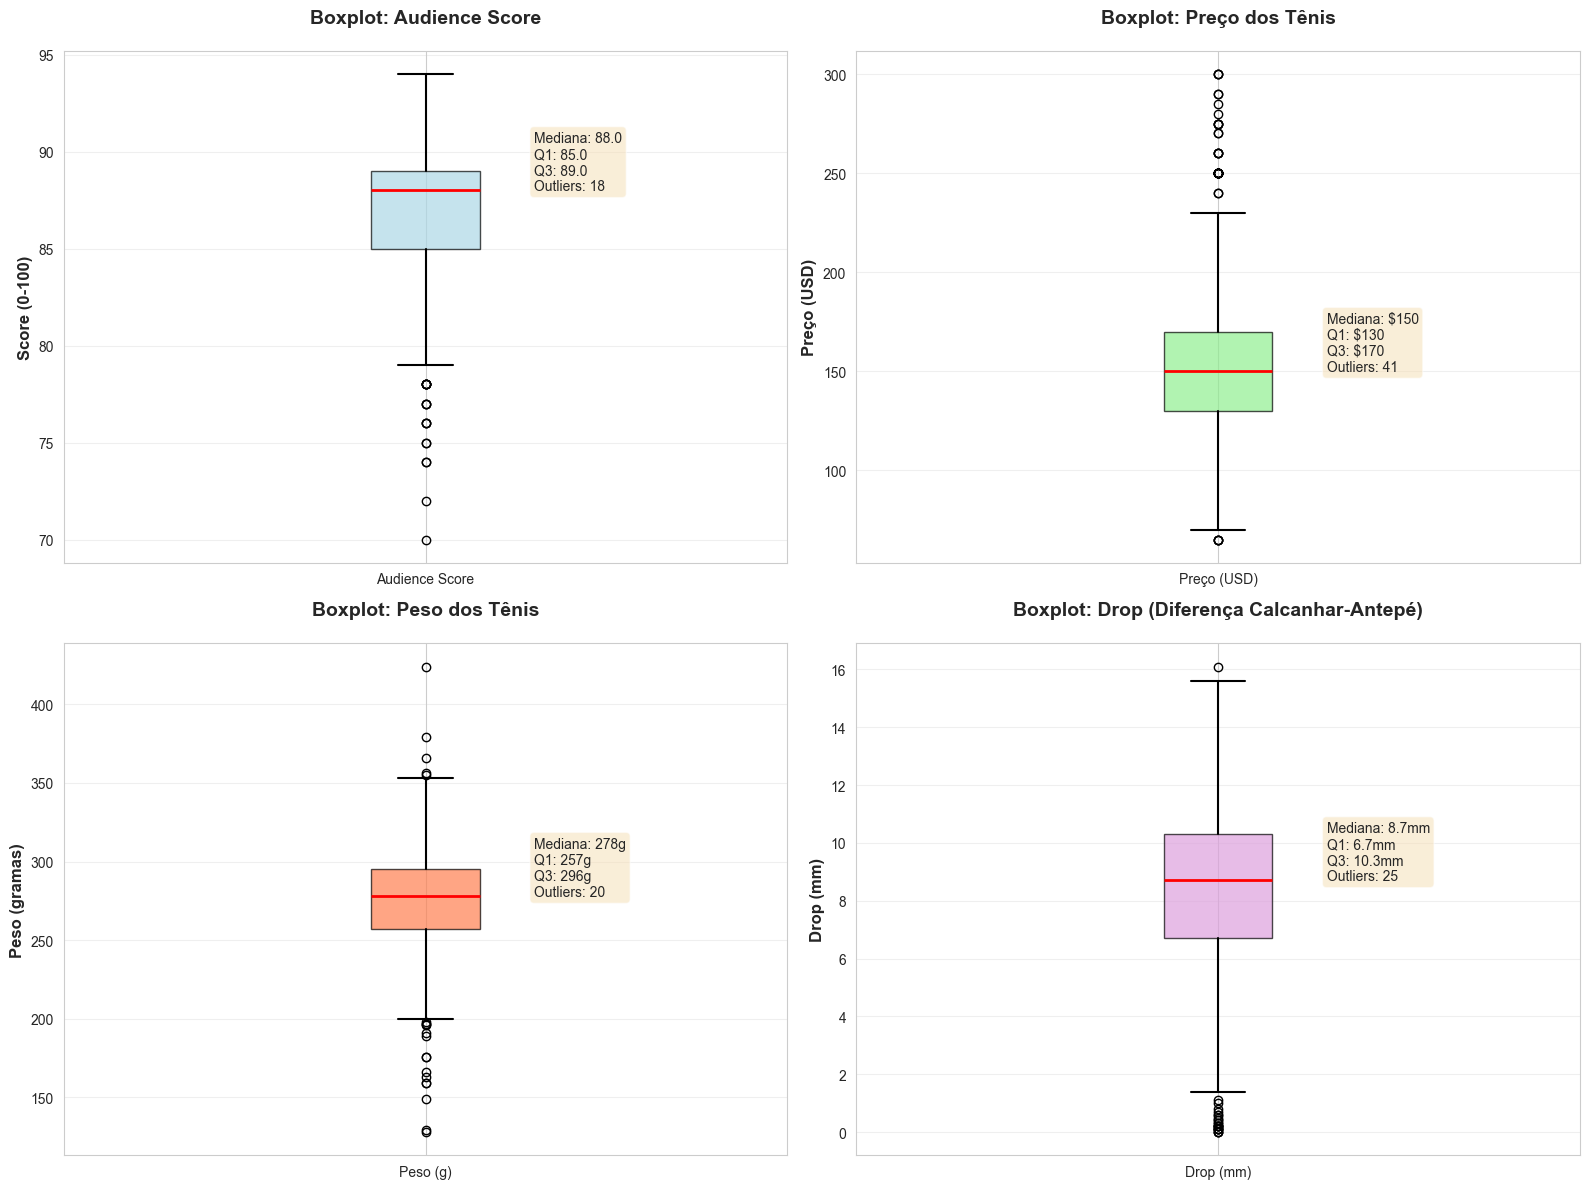


 INTERPRETAÇÃO - Boxplots e Outliers:

 Outliers Detectados:
   • Audience Score: 18 outliers
     Valores: [70.0, 72.0, 74.0, 74.0, 75.0]
   • Preço: 41 outliers
     Valores mais altos: [300.0, 300.0, 300.0, 290.0, 290.0]
   • Peso: 20 outliers
     Valores extremos: [128.0, 129.0, 149.0] e [424.0, 379.0, 366.0]
   • Drop: 25 outliers
     Valores: [0.0, 0.0, 0.0, 0.1, 0.1]

 Conclusões:
   • A presença de outliers pode indicar tênis especializados
   • Outliers em preço podem ser modelos premium ou de edição limitada
   • Outliers em peso podem indicar tênis de trail ou ultra-maratona
   • A mediana é mais robusta que a média para dados com outliers


In [4]:
# Boxplots para detectar outliers
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Boxplot 1: Audience Score
ax1 = axes[0, 0]
bp1 = ax1.boxplot([scores], vert=True, patch_artist=True, labels=['Audience Score'],
                   boxprops=dict(facecolor='lightblue', alpha=0.7),
                   medianprops=dict(color='red', linewidth=2),
                   whiskerprops=dict(linewidth=1.5),
                   capprops=dict(linewidth=1.5))
ax1.set_ylabel('Score (0-100)', fontsize=12, fontweight='bold')
ax1.set_title('Boxplot: Audience Score', fontsize=14, fontweight='bold', pad=20)
ax1.grid(axis='y', alpha=0.3)

# Estatísticas
q1_s, q3_s = scores.quantile(0.25), scores.quantile(0.75)
iqr_s = q3_s - q1_s
outliers_s = scores[(scores < q1_s - 1.5*iqr_s) | (scores > q3_s + 1.5*iqr_s)]
ax1.text(1.15, scores.median(), f'Mediana: {scores.median():.1f}\nQ1: {q1_s:.1f}\nQ3: {q3_s:.1f}\nOutliers: {len(outliers_s)}',
        fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Boxplot 2: Preço
ax2 = axes[0, 1]
bp2 = ax2.boxplot([prices], vert=True, patch_artist=True, labels=['Preço (USD)'],
                   boxprops=dict(facecolor='lightgreen', alpha=0.7),
                   medianprops=dict(color='red', linewidth=2),
                   whiskerprops=dict(linewidth=1.5),
                   capprops=dict(linewidth=1.5))
ax2.set_ylabel('Preço (USD)', fontsize=12, fontweight='bold')
ax2.set_title('Boxplot: Preço dos Tênis', fontsize=14, fontweight='bold', pad=20)
ax2.grid(axis='y', alpha=0.3)

q1_p, q3_p = prices.quantile(0.25), prices.quantile(0.75)
iqr_p = q3_p - q1_p
outliers_p = prices[(prices < q1_p - 1.5*iqr_p) | (prices > q3_p + 1.5*iqr_p)]
ax2.text(1.15, prices.median(), f'Mediana: ${prices.median():.0f}\nQ1: ${q1_p:.0f}\nQ3: ${q3_p:.0f}\nOutliers: {len(outliers_p)}',
        fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Boxplot 3: Peso
ax3 = axes[1, 0]
bp3 = ax3.boxplot([weights], vert=True, patch_artist=True, labels=['Peso (g)'],
                   boxprops=dict(facecolor='coral', alpha=0.7),
                   medianprops=dict(color='red', linewidth=2),
                   whiskerprops=dict(linewidth=1.5),
                   capprops=dict(linewidth=1.5))
ax3.set_ylabel('Peso (gramas)', fontsize=12, fontweight='bold')
ax3.set_title('Boxplot: Peso dos Tênis', fontsize=14, fontweight='bold', pad=20)
ax3.grid(axis='y', alpha=0.3)

q1_w, q3_w = weights.quantile(0.25), weights.quantile(0.75)
iqr_w = q3_w - q1_w
outliers_w = weights[(weights < q1_w - 1.5*iqr_w) | (weights > q3_w + 1.5*iqr_w)]
ax3.text(1.15, weights.median(), f'Mediana: {weights.median():.0f}g\nQ1: {q1_w:.0f}g\nQ3: {q3_w:.0f}g\nOutliers: {len(outliers_w)}',
        fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Boxplot 4: Drop
ax4 = axes[1, 1]
bp4 = ax4.boxplot([drops], vert=True, patch_artist=True, labels=['Drop (mm)'],
                   boxprops=dict(facecolor='plum', alpha=0.7),
                   medianprops=dict(color='red', linewidth=2),
                   whiskerprops=dict(linewidth=1.5),
                   capprops=dict(linewidth=1.5))
ax4.set_ylabel('Drop (mm)', fontsize=12, fontweight='bold')
ax4.set_title('Boxplot: Drop (Diferença Calcanhar-Antepé)', fontsize=14, fontweight='bold', pad=20)
ax4.grid(axis='y', alpha=0.3)

q1_d, q3_d = drops.quantile(0.25), drops.quantile(0.75)
iqr_d = q3_d - q1_d
outliers_d = drops[(drops < q1_d - 1.5*iqr_d) | (drops > q3_d + 1.5*iqr_d)]
ax4.text(1.15, drops.median(), f'Mediana: {drops.median():.1f}mm\nQ1: {q1_d:.1f}mm\nQ3: {q3_d:.1f}mm\nOutliers: {len(outliers_d)}',
        fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("\n INTERPRETAÇÃO - Boxplots e Outliers:")
print("="*80)
print(f"\n Outliers Detectados:")
print(f"   • Audience Score: {len(outliers_s)} outliers")
if len(outliers_s) > 0:
    print(f"     Valores: {sorted(outliers_s.tolist())[:5]}")
print(f"   • Preço: {len(outliers_p)} outliers")
if len(outliers_p) > 0:
    print(f"     Valores mais altos: {sorted(outliers_p.tolist(), reverse=True)[:5]}")
print(f"   • Peso: {len(outliers_w)} outliers")
if len(outliers_w) > 0:
    print(f"     Valores extremos: {sorted(outliers_w.tolist())[:3]} e {sorted(outliers_w.tolist(), reverse=True)[:3]}")
print(f"   • Drop: {len(outliers_d)} outliers")
if len(outliers_d) > 0:
    print(f"     Valores: {sorted(outliers_d.tolist())[:5]}")

print(f"\n Conclusões:")
print(f"   • A presença de outliers pode indicar tênis especializados")
print(f"   • Outliers em preço podem ser modelos premium ou de edição limitada")
print(f"   • Outliers em peso podem indicar tênis de trail ou ultra-maratona")
print(f"   • A mediana é mais robusta que a média para dados com outliers")

## 3.4 Conclusões da Análise Univariada


#### Distribuições Categóricas:
- **Marcas:** Mercado concentrado nas principais marcas esportivas
- **Suporte:** Maioria dos tênis é neutra, refletindo tendência do mercado
- **Uso:** Predominância de tênis para corrida diária
- **Pisada:** Padrão de calcanhar/médio-pé mais comum

#### Distribuições Numéricas:
- **Score:** Distribuição concentrada em valores altos (boa qualidade geral)
- **Preço:** Distribuição com cauda à direita (alguns modelos premium)
- **Peso:** Distribuição aproximadamente normal
- **Drop:** Variação moderada, com concentração em 8-10mm

#### Outliers:
- Outliers identificados são válidos (modelos especializados)
- Não há indicação de erros de medição
- Manter outliers para análises de segmentação

### Recomendações:
1. Considerar segmentação por faixa de preço
2. Analisar relação entre peso e tipo de uso
3. Investigar marcas premium (outliers de preço)
4. Explorar correlações entre variáveis (próxima etapa)